# Creating ability groups based on IRT theta

## Install IRT

In [ ]:
!pip install -q py-irt

## Imports

In [ ]:
import os
import random
import pandas as pd
import numpy as np
import torch
import pyro
from py_irt.models.one_param_logistic import OneParamLog

## Set random seed

In [ ]:
# Set a seed so stochastic parts of the analysis are reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)

## Import dataset and create paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/education-ml-research/ASSISTments2009"

DATA_PATH = os.path.join(
    DATA_DIR,
    "skill_builder_data.csv"
)

# Path where final IRT ability-group file will be saved
ABILITY_GROUP_PATH = os.path.join(
    DATA_DIR,
    "student_irt_ability_groups.csv"
)

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print("Dataset shape:", df.shape)
print("Number of students:", df["user_id"].nunique())
print("Number of skills:", df["skill_id"].nunique())

Mounted at /content/drive


/tmp/ipykernel_1930/1602560932.py:17: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dataset shape: (525534, 30)
Number of students: 4217
Number of skills: 123


## Prepare data for IRT

In [ ]:
# Keep only the columns needed for the IRT model
irt_df = df[
    ["user_id", "skill_id", "correct"]
].copy()

# Remove rows where the student or skill is missing
irt_df = irt_df.dropna(
    subset=["user_id", "skill_id"]
)

# Make sure the response variable is numeric
irt_df["correct"] = pd.to_numeric(
    irt_df["correct"],
    errors="coerce"
)

# Keep only valid binary responses: 0 = incorrect, 1 = correct
irt_df = irt_df[
    irt_df["correct"].isin([0, 1])
].copy()

# Reset the row numbers after removing observations
irt_df = irt_df.reset_index(drop=True)

print("Valid IRT interactions:", len(irt_df))
print("Students:", irt_df["user_id"].nunique())
print("Skills:", irt_df["skill_id"].nunique())

Valid IRT interactions: 459208
Students: 4163
Skills: 123


## Create numerical indices for skills and students

In [ ]:
# Get the unique student and skill IDs
student_ids = np.sort(
    irt_df["user_id"].unique()
)

skill_ids = np.sort(
    irt_df["skill_id"].unique()
)

# Create a numerical mapping from the original student IDs
student_to_idx = {
    student_id: i
    for i, student_id in enumerate(student_ids)
}

# Create the same type of mapping for skills
skill_to_idx = {
    skill_id: i
    for i, skill_id in enumerate(skill_ids)
}

print("Number of students:", len(student_ids))
print("Number of skills:", len(skill_ids))
print("First student IDs:", student_ids[:5])
print("First student indices:", list(student_to_idx.items())[:5])

Number of students: 4163
Number of skills: 123
First student IDs: [   14 21825 51950 52613 53167]
First student indices: [(np.int64(14), 0), (np.int64(21825), 1), (np.int64(51950), 2), (np.int64(52613), 3), (np.int64(53167), 4)]


## Add indices to data

In [ ]:
# Convert each original student ID into its numerical IRT index
irt_df["model"] = irt_df["user_id"].map(
    student_to_idx
)

# Convert each original skill ID into its numerical IRT index
irt_df["item"] = irt_df["skill_id"].map(
    skill_to_idx
)

# Check the result
print(
    irt_df[
        ["user_id", "skill_id", "correct", "model", "item"]
    ].head()
)

print("Missing student indices:", irt_df["model"].isna().sum())
print("Missing skill indices:", irt_df["item"].isna().sum())

   user_id  skill_id  correct  model  item
0    64525       1.0        1      7     0
1    64525       1.0        1      7     0
2    70363       1.0        0     15     0
3    70363       1.0        1     15     0
4    70363       1.0        0     15     0
Missing student indices: 0
Missing skill indices: 0


## Convert to Pytorch tensors

In [ ]:
# Convert student indices into a PyTorch tensor
models = torch.tensor(
    irt_df["model"].values,
    dtype=torch.long
)

# Convert skill indices into a PyTorch tensor
items = torch.tensor(
    irt_df["item"].values,
    dtype=torch.long
)

# Convert 0/1 responses into a PyTorch tensor
responses = torch.tensor(
    irt_df["correct"].values,
    dtype=torch.float32
)

# Check the tensors
print("Models shape:", models.shape)
print("Items shape:", items.shape)
print("Responses shape:", responses.shape)

Models shape: torch.Size([459208])
Items shape: torch.Size([459208])
Responses shape: torch.Size([459208])


## Validate tensors

In [ ]:
# Use the CPU for IRT fitting
device = "cpu"

# Move all tensors to the selected device
models = models.to(device)
items = items.to(device)
responses = responses.to(device)

# Clear parameters from any previous Pyro model runs
pyro.clear_param_store()

# Validate the tensor contents
print("Number of interactions:", len(responses))
print("Number of students:", len(student_ids))
print("Number of skills:", len(skill_ids))

print("Minimum student index:", models.min().item())
print("Maximum student index:", models.max().item())

print("Minimum skill index:", items.min().item())
print("Maximum skill index:", items.max().item())

print("Unique response values:", torch.unique(responses))

Number of interactions: 459208
Number of students: 4163
Number of skills: 123
Minimum student index: 0
Maximum student index: 4162
Minimum skill index: 0
Maximum skill index: 122
Unique response values: tensor([0., 1.])


## Create and fit IRT model

In [ ]:
# Create the 1PL IRT model
irt_model = OneParamLog(
    priors="hierarchical",
    device=device,
    num_items=len(skill_ids),
    num_models=len(student_ids),
    verbose=True
)

# Number of fitting epochs
NUM_EPOCHS = 1000

# Fit the IRT model to the student response data
irt_model.fit(
    models=models,
    items=items,
    responses=responses,
    num_epochs=NUM_EPOCHS
)

[epoch 0001] loss: 30868522.7474
[epoch 0101] loss: 261324.4257
[epoch 0201] loss: 265641.3193
[epoch 0301] loss: 260664.2477
[epoch 0401] loss: 263162.6052
[epoch 0501] loss: 292663.1492
[epoch 0601] loss: 255771.9145
[epoch 0701] loss: 267514.7656
[epoch 0801] loss: 271840.2350
[epoch 0901] loss: 280095.1211
[epoch 1000] loss: 263029.7377


## Extract IRT ability estimates

In [ ]:
# Get the parameters learned by the IRT model
param_store = pyro.get_param_store()

# Extract the estimated ability (theta) for each student
theta = (
    param_store["loc_ability"]
    .detach()
    .cpu()
    .numpy()
)

# Create a table connecting each student to their IRT ability
irt_scores = pd.DataFrame({
    "user_id": student_ids,
    "theta": theta
})

# Basic checks
print("Number of theta estimates:", len(theta))
print("Number of students:", len(student_ids))
print()
print(irt_scores.head())

# Display summary statistics for the IRT ability estimates
print(irt_scores["theta"].describe())

# Check for missing theta values
print(
    "\nMissing theta values:",
    irt_scores["theta"].isna().sum()
)

# Check for infinite theta values
print(
    "Infinite theta values:",
    np.isinf(irt_scores["theta"]).sum()
)

Number of theta estimates: 4163
Number of students: 4163

   user_id     theta
0       14 -1.597221
1    21825  0.165185
2    51950  0.953936
3    52613 -1.125967
4    53167 -0.213702
count    4163.000000
mean       -0.350464
std         1.757900
min        -7.918318
25%        -1.195186
50%        -0.293039
75%         0.524573
max         6.649147
Name: theta, dtype: float64

Missing theta values: 0
Infinite theta values: 0


## Theta visualization

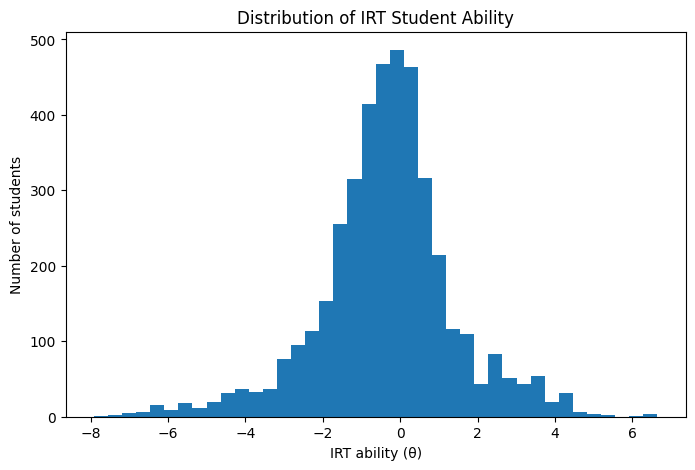

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    irt_scores["theta"],
    bins=40
)

plt.xlabel("IRT ability (θ)")
plt.ylabel("Number of students")
plt.title("Distribution of IRT Student Ability")

plt.show()

## Create theta ability quartiles

In [ ]:
# Divide students into four equally sized groups based on IRT ability
irt_scores["theta_quartile"] = pd.qcut(
    irt_scores["theta"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

# Check the number of students in each quartile
print(
    irt_scores["theta_quartile"]
    .value_counts()
    .sort_index()
)

theta_quartile
Q1    1041
Q2    1041
Q3    1040
Q4    1041
Name: count, dtype: int64


## Calculate theta standard deviation boundaries

In [ ]:
theta_sd = irt_scores["theta"].std()

print("Theta SD:", theta_sd)

sd_multipliers = np.array([
    -np.inf,
    -1.5,
    -1.0,
    -0.5,
     0.0,
     0.5,
     1.0,
     1.5,
     np.inf
])

theta_sd_boundaries = (
    sd_multipliers * theta_sd
)

print(theta_sd_boundaries)

Theta SD: 1.7578997611999512
[       -inf -2.63684964 -1.75789976 -0.87894988  0.          0.87894988
  1.75789976  2.63684964         inf]


## Create SD groups

In [ ]:
sd_labels = [
    "< -1.5 SD",
    "-1.5 to -1.0 SD",
    "-1.0 to -0.5 SD",
    "-0.5 to 0 SD",
    "0 to +0.5 SD",
    "+0.5 to +1.0 SD",
    "+1.0 to +1.5 SD",
    "> +1.5 SD"
]

irt_scores["theta_sd_group"] = pd.cut(
    irt_scores["theta"],
    bins=theta_sd_boundaries,
    labels=sd_labels,
    include_lowest=True
)

print(
    irt_scores["theta_sd_group"]
    .value_counts()
    .sort_index()
)

theta_sd_group
< -1.5 SD           351
-1.5 to -1.0 SD     299
-1.0 to -0.5 SD     704
-0.5 to 0 SD       1129
0 to +0.5 SD        933
+0.5 to +1.0 SD     381
+1.0 to +1.5 SD     150
> +1.5 SD           216
Name: count, dtype: int64


## Verify that each student is assigned theta and into both distributions

In [ ]:
print(
    irt_scores[
        ["user_id", "theta", "theta_quartile", "theta_sd_group"]
    ].head(20)
)

    user_id     theta theta_quartile   theta_sd_group
0        14 -1.597221             Q1  -1.0 to -0.5 SD
1     21825  0.165185             Q3     0 to +0.5 SD
2     51950  0.953936             Q4  +0.5 to +1.0 SD
3     52613 -1.125967             Q2  -1.0 to -0.5 SD
4     53167 -0.213702             Q3     -0.5 to 0 SD
5     54318  0.475023             Q3     0 to +0.5 SD
6     58161 -1.625268             Q1  -1.0 to -0.5 SD
7     64525  0.776447             Q4     0 to +0.5 SD
8     64531  3.771690             Q4        > +1.5 SD
9     64532  3.934636             Q4        > +1.5 SD
10    64535 -0.035920             Q3     -0.5 to 0 SD
11    64550  4.109382             Q4        > +1.5 SD
12    64634 -1.016508             Q2  -1.0 to -0.5 SD
13    69931 -1.204094             Q1  -1.0 to -0.5 SD
14    70190 -0.809802             Q2     -0.5 to 0 SD
15    70363 -0.621651             Q2     -0.5 to 0 SD
16    70657 -4.848576             Q1        < -1.5 SD
17    70676  0.727413       

## Save student groups

In [ ]:
ability_groups = irt_scores[
    [
        "user_id",
        "theta",
        "theta_quartile",
        "theta_sd_group"
    ]
].copy()

ability_groups.to_csv(
    ABILITY_GROUP_PATH,
    index=False
)

print("Saved:", ABILITY_GROUP_PATH)

Saved: /content/drive/MyDrive/education-ml-research/ASSISTments2009/student_irt_ability_groups.csv
